<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

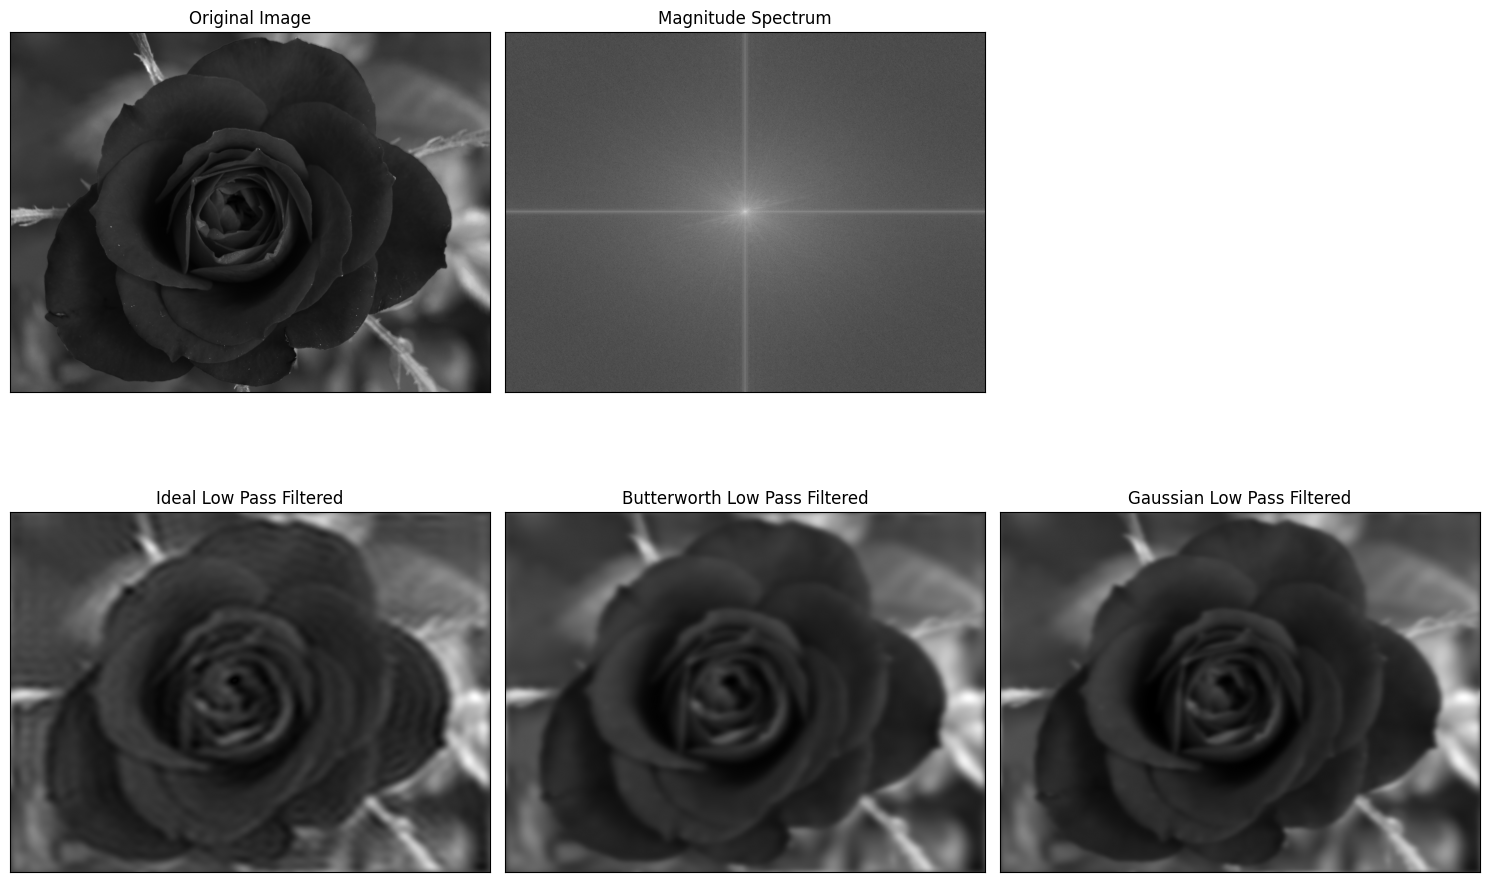

In [ ]:
import urllib.request
import cv2
import numpy as np
from scipy import fftpack
import matplotlib.pyplot as plt

def exp4_frequency_domain():
    # --------------------------------------------------------
    # STEP 1: Download and read the image
    # --------------------------------------------------------
    url = "https://upload.wikimedia.org/wikipedia/commons/5/51/Small_Red_Rose.JPG"

    # Create a Request object with a User-Agent header
    # This helps mimic a browser request and can bypass some 403 errors
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

    try:
        with urllib.request.urlopen(req) as response:
            with open("rose_flower.png", 'wb') as out_file:
                out_file.write(response.read())
    except urllib.error.HTTPError as e:
        print(f"HTTP Error: {e.code} - {e.reason}")
        print("Could not download the image. Please check the URL or your network connection.")
        return # Exit the function if download fails

    # Read image in grayscale
    img = cv2.imread("rose_flower.png", 0)
    if img is None:
        print("Error: Could not read the downloaded image. It might be corrupted or not a valid image file.")
        return

    # --------------------------------------------------------
    # STEP 2: Apply Fourier Transform
    # --------------------------------------------------------
    # Convert image from spatial domain to frequency domain
    f = fftpack.fft2(img.astype(float))
    # Shift zero frequency component to center
    fshift = fftpack.fftshift(f)
    # Calculate magnitude spectrum for visualization
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

    # --------------------------------------------------------
    # STEP 3: Create Filters
    # --------------------------------------------------------
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2 # center point
    d = 30 # cutoff frequency

    # -------------------- Ideal Low Pass Filter -------------------
    # Allows only frequencies within cutoff radius
    ideal_mask = np.zeros((rows, cols), np.uint8)
    ideal_mask[crow-d:crow+d, ccol-d:ccol+d] = 1

    # -------------------- Butterworth Low Pass Filter -----------------
    butter_mask = np.zeros((rows, cols))
    for u in range(rows):
        for v in range(cols):
            dist = np.sqrt((u-crow)**2 + (v-ccol)**2)
            if dist == 0: # Avoid division by zero
                butter_mask[u, v] = 1
            else:
                butter_mask[u, v] = 1 / (1 + (dist / d)**4)

    # -------------------- Gaussian Low Pass Filter -------------------
    gaussian_mask = np.zeros((rows, cols))
    for u in range(rows):
        for v in range(cols):
            dist = np.sqrt((u-crow)**2 + (v-ccol)**2)
            gaussian_mask[u, v] = np.exp(-(dist**2) / (2 * d**2))

    # ------------------------------------------------------
    # STEP 4: Apply filters in frequency domain
    # ------------------------------------------------------
    def apply_filter(frequency_domain_image, mask):
        # Apply the filter mask
        filtered_fshift = frequency_domain_image * mask

        # Shift zero frequency component back
        f_ishift = fftpack.ifftshift(filtered_fshift)

        # Perform inverse Fourier Transform
        img_back = fftpack.ifft2(f_ishift)

        # Take real part and normalize to 0-255
        img_back = np.abs(img_back)
        img_back = np.uint8(cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX))

        return img_back

    # Apply Ideal Low Pass Filter
    img_ideal_lp = apply_filter(fshift, ideal_mask)

    # Apply Butterworth Low Pass Filter
    img_butter_lp = apply_filter(fshift, butter_mask)

    # Apply Gaussian Low Pass Filter
    img_gaussian_lp = apply_filter(fshift, gaussian_mask)

    # ------------------------------------------------------
    # STEP 5: Display results
    # ------------------------------------------------------
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1), plt.imshow(img, cmap='gray')
    plt.title('Original Image'), plt.xticks([]), plt.yticks([])

    plt.subplot(2, 3, 2), plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])

    plt.subplot(2, 3, 4), plt.imshow(img_ideal_lp, cmap='gray')
    plt.title('Ideal Low Pass Filtered'), plt.xticks([]), plt.yticks([])

    plt.subplot(2, 3, 5), plt.imshow(img_butter_lp, cmap='gray')
    plt.title('Butterworth Low Pass Filtered'), plt.xticks([]), plt.yticks([])

    plt.subplot(2, 3, 6), plt.imshow(img_gaussian_lp, cmap='gray')
    plt.title('Gaussian Low Pass Filtered'), plt.xticks([]), plt.yticks([])

    plt.tight_layout()
    plt.show()

exp4_frequency_domain()